Running Patient Zero Simulation...


100%|██████████| 5000/5000 [00:08<00:00, 575.58it/s]


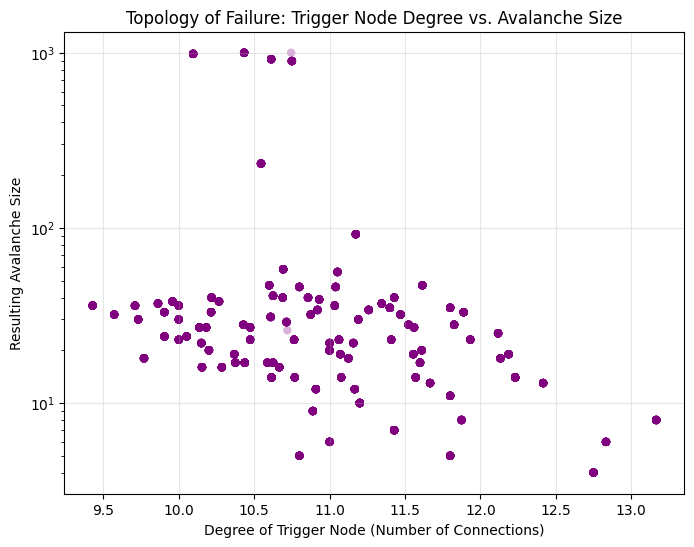

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def analyze_ignition_topology(NUM_NODES=1000, RADIUS=0.06, TOL=0.20, NOISE=0.8, STEPS=5000):
    G = nx.random_geometric_graph(NUM_NODES, radius=RADIUS)

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    ignition_data = [] # Stores tuples: (Degree of Patient Zero, Final Avalanche Size)

    print("Running Patient Zero Simulation...")
    for step in tqdm(range(STEPS)):
        for node in G.nodes(): G.nodes[node]['load'] += (NOISE / 10.0)

        current_avalanche = 0
        patient_zeros = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]

        # Record the degree of the nodes starting the cascade
        trigger_degrees = [G.degree(n) for n in patient_zeros]

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche += 1

                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs: G.nodes[nbr]['load'] += spill

        if current_avalanche > 0 and trigger_degrees:
            # We take the average degree if multiple nodes tripped simultaneously at tick start
            avg_trigger_degree = np.mean(trigger_degrees)
            ignition_data.append((avg_trigger_degree, current_avalanche))

        for node in G.nodes(): G.nodes[node]['tripped'] = False

    return ignition_data

# --- PLOTTING ---
data = analyze_ignition_topology()
degrees = [d[0] for d in data]
sizes = [d[1] for d in data]

plt.figure(figsize=(8, 6))
plt.scatter(degrees, sizes, alpha=0.3, color='purple', edgecolors='none')
plt.title("Topology of Failure: Trigger Node Degree vs. Avalanche Size")
plt.xlabel("Degree of Trigger Node (Number of Connections)")
plt.ylabel("Resulting Avalanche Size")
plt.yscale('log') # Log scale helps visualize the massive variance
plt.grid(True, alpha=0.3)
plt.show()